# Static RPA screened interaction
An electron and a hole added to a solid do not feel the bare interaction: the other electrons
rearrange around them, and what survives that rearrangement is the screened interaction. Once a
mean-field calculation has left the bands on a k-mesh, the static RPA screening can be computed
from them directly rather than postulated,

$$
\varepsilon(q) = 1 - v(q)\chi^0(q), \qquad W(q) = \varepsilon^{-1}(q)\, v(q)
$$

with $\chi^0(q)$ the static polarizability of those bands. `h.get_screened_interaction()`
computes it, building the dielectric matrix in the charge channel as in GW: what polarizes the
medium is the total density, and the correction that comes back is spin independent, which keeps
the result spin-rotation invariant. The same $W$ can be used as the direct term of the
Bethe-Salpeter equation, `h.get_bse(screening="rpa")`, GW-BSE style, with the constrained RPA,
`screening="crpa"`, as an option when a band window is to be solved exactly afterwards.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.bsetk.interaction import density_interaction, interaction_at_q

### The screened interaction across the Brillouin zone
We take a honeycomb lattice with a sublattice imbalance, a gapped two-band semiconductor, and a
*bare* interaction made of an onsite $U$ and a Coulomb tail, softened at short distance and
cut off exponentially at long distance, as a metallic gate would do. Note that a
Hubbard $U$ fitted to a material is already an effective, screened interaction, and must not be
screened a second time. We then compare, over the Brillouin zone, the charge-channel bare
interaction on one sublattice, $v_{AA}(q)$, with the correction that screening adds to it,
$W_{AA}(q)-v_{AA}(q)$.

smallest dielectric eigenvalue over the mesh = 0.7686112628331271


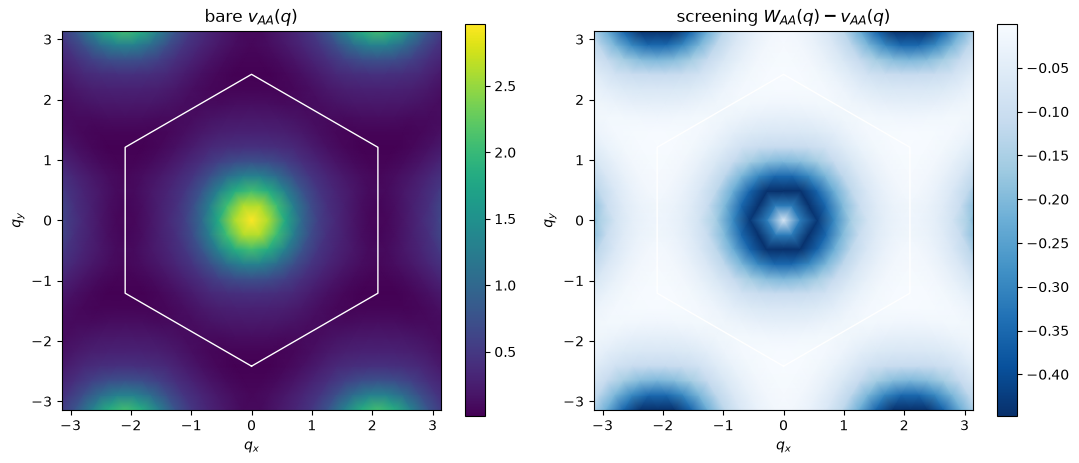

In [2]:
g = geometry.honeycomb_lattice() # two sites per unit cell
h = g.get_hamiltonian() # first-neighbor hopping
h.add_sublattice_imbalance(0.5) # open a gap, a two-band semiconductor

def coulomb(r1,r2): # Coulomb tail, soft at short distance, cut off by a gate at long distance
    d = np.sqrt((r1-r2).dot(r1-r2))
    return 1.0*np.exp(-d/2.)/np.sqrt(d**2+0.25)
V = density_interaction(h,U=1.0,Vr=coulomb) # a BARE interaction

nk = 15 # k-mesh, and q-mesh W is tabulated on
W = h.get_screened_interaction(V=V,nk=nk) # screened interaction
print("smallest dielectric eigenvalue over the mesh =",W.epsmin)

def charge(M): # spin-orbital matrix -> site matrix, charge channel
    n = M.shape[0]//2
    return np.array([[np.sum(M[2*i:2*i+2,2*j:2*j+2])/4. for j in range(n)] for i in range(n)])

vAA,dWAA = [],[]
for iq,q in enumerate(W.qs):
    vq = charge(interaction_at_q(W.bare,g,q)) # bare interaction at q
    wq = charge(W.Wq[iq]) # screened interaction at q
    vAA.append(vq[0,0].real) ; dWAA.append((wq-vq)[0,0].real)

# unfold the mesh to Cartesian momenta around the center of the zone
A = np.array([g.a1[:2],g.a2[:2]]) # lattice vectors as rows
b = 2*np.pi*np.linalg.inv(A).T # reciprocal lattice vectors as rows
Q,vm,dm = [],[],[]
for s1 in [-2,-1,0,1,2]:
    for s2 in [-2,-1,0,1,2]:
        for iq,q in enumerate(W.qs):
            Q.append((q[0]+s1)*b[0] + (q[1]+s2)*b[1])
            vm.append(vAA[iq]) ; dm.append(dWAA[iq])
Q = np.array(Q)
G = [n1*b[0]+n2*b[1] for n1 in [-1,0,1] for n2 in [-1,0,1] if (n1,n2)!=(0,0)]
G = sorted(G,key=np.linalg.norm)[0:6] # the six shortest reciprocal lattice vectors
G = sorted(G,key=lambda v: np.arctan2(v[1],v[0])) # sorted by angle
hexagon = np.array([(G[i%6]+G[(i+1)%6])/3. for i in range(7)]) # corners of the zone, the K points
Kmag = np.linalg.norm(hexagon[0]) # distance to the K points
fig,axs = plt.subplots(1,2,figsize=(11,4.5))
for ax,data,label,cmap in [(axs[0],vm,"bare $v_{AA}(q)$","viridis"),
                           (axs[1],dm,"screening $W_{AA}(q)-v_{AA}(q)$","Blues_r")]:
    im = ax.tripcolor(Q[:,0],Q[:,1],data,shading="gouraud",cmap=cmap)
    ax.plot(hexagon[:,0],hexagon[:,1],c="white",lw=1) # first Brillouin zone
    ax.set_xlim([-1.3*Kmag,1.3*Kmag]) ; ax.set_ylim([-1.3*Kmag,1.3*Kmag])
    ax.set_aspect("equal") ; ax.set_xlabel("$q_x$") ; ax.set_ylabel("$q_y$")
    ax.set_title(label) ; plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()

The correction is negative everywhere, so screening reduces the interaction, and it vanishes at
$q=0$: a uniform potential cannot move charge around in an insulator, so there is nothing to
screen it with. It is largest on a ring close to the center of the zone, at the long wavelengths
where the bare interaction is also largest, and small at the zone boundary.
### Screened interaction in real space
`W.get_dict()` Fourier transforms $W(q)$ back to real space, which shows how far the screened
interaction reaches, and gives something that can be evaluated at any $q$ or passed to a
screened-exchange mean field.

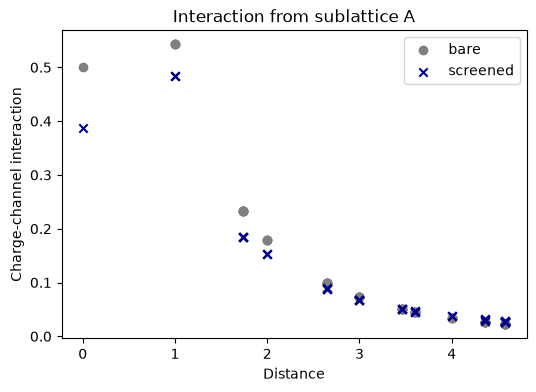

In [3]:
Wr = W.get_dict() # screened interaction in real space, (n1,n2,n3) -> matrix
rs,vs,ws = [],[],[]
for R,m in Wr.items():
    mb = W.bare.get(R,0.*m) # bare interaction to the same cell
    r = R[0]*np.array(g.a1) + R[1]*np.array(g.a2) # cell position
    for j in range(len(g.r)): # from site A of cell 0 to site j of cell R
        rs.append(np.linalg.norm(g.r[j] + r - g.r[0]))
        ws.append(np.sum(m[0:2,2*j:2*j+2]).real/4.) # charge channel, screened
        vs.append(np.sum(mb[0:2,2*j:2*j+2]).real/4.) # charge channel, bare
rs,vs,ws = np.array(rs),np.array(vs),np.array(ws)
keep = rs<5.
plt.figure(figsize=(6,4))
plt.scatter(rs[keep],vs[keep],label="bare",c="gray")
plt.scatter(rs[keep],ws[keep],label="screened",c="darkblue",marker="x")
plt.xlabel("Distance") ; plt.ylabel("Charge-channel interaction")
plt.legend() ; plt.title("Interaction from sublattice A")
plt.show()

### What screening does to the exciton
Putting $W$ in the direct term of the Bethe-Salpeter equation weakens the attraction between the
electron and the hole, so the exciton binds less, while the exchange term keeps the bare
interaction.

In [4]:
bare = h.get_bse(V=V,nk=8) # time-dependent Hartree-Fock
screened = h.get_bse(V=V,nk=8,screening="rpa") # GW-BSE style
print("binding energy, bare interaction     =",bare.get_binding_energies(1)[0].real)
print("binding energy, screened interaction =",screened.get_binding_energies(1)[0].real)

binding energy, bare interaction     = 0.11752280523641212
binding energy, screened interaction = 0.10751127095897073
